# Credit Risk Prediction — Feature Engineering

**Author:** Aluka Precious Oluchukwu
**Project:** Credit Risk ML System Feature Engineering

## Overview

This notebook transforms the cleaned and decoded dataset produced in Phase 2 
into a fully preprocessed, model-ready dataset. Feature engineering bridges 
the gap between human-readable data and the numerical representations that 
machine learning algorithms require to learn patterns effectively.

The key operations performed in this phase are:

1. Loading the cleaned dataset
2. Encoding categorical features into numerical representations
3. Scaling numerical features to a common range
4. Splitting data into training and test sets
5. Applying SMOTE to correct class imbalance on training data only
6. Saving the final processed dataset for model training

In [10]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported succesfully")

Libraries imported succesfully


In [11]:
# ─── Load cleaned dataset
df = pd.read_csv("../data/processed/Cleaned_credit_risk_data.csv")



In [12]:

# ─── Confirm successful load ──────────────────────────────────────────────────
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 3 rows:")
df.head(3)

Dataset loaded successfully!
Shape: (1000, 21)

Column names:
['checking account status', 'Duration in month', 'Credit history', 'Purpose', 'Credit amount', 'Savings account/bonds', 'employment', 'Installment', 'status n sex', 'Other debtors / guarantors', 'residence', 'Property', 'Age in years', 'Other installment plans', 'Housing', 'existing credits no.', 'Job', 'liability responsibles', 'Telephone', 'foreign worker', 'Category']

Data types:
checking account status       object
Duration in month              int64
Credit history                object
Purpose                       object
Credit amount                  int64
Savings account/bonds         object
employment                    object
Installment                    int64
status n sex                  object
Other debtors / guarantors    object
residence                      int64
Property                      object
Age in years                   int64
Other installment plans       object
Housing                       obj

,checking account status,Duration in month,Credit history,Purpose,Credit amount,Savings account/bonds,employment,Installment,status n sex,Other debtors / guarantors,...,Property,Age in years,Other installment plans,Housing,existing credits no.,Job,liability responsibles,Telephone,foreign worker,Category
0,less_than_0_DM,6,critical_account,radio_tv,1169,unknown_no_savings,greater_than_7_years,4,male_single,none,...,real_estate,67,none,own,2,skilled_employee,1,yes_registered,yes,0
1,0_to_200_DM,48,existing_credits_paid_duly,radio_tv,5951,less_than_100_DM,1_to_4_years,2,female_divorced_separated_married,none,...,real_estate,22,none,own,1,skilled_employee,1,none,yes,1
2,no_checking_account,12,critical_account,education,2096,less_than_100_DM,4_to_7_years,2,male_single,none,...,real_estate,49,none,own,1,unskilled_resident,2,none,yes,0


## 1. Identifying Features for Encoding and Scaling

Before transforming anything we first separate our columns into three groups:

- **Categorical columns** — text labels that need encoding into numbers
- **Numerical columns** — numbers that need scaling to a common range
- **Target column** — Category which we separate entirely

This separation ensures we apply the right transformation to the right columns
without accidentally scaling something that should be encoded or encoding
something that should be scaled.

In [13]:
# ─── Separate columns by type ─────────────────────────────────────────────────
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target variable from numerical columns
numerical_cols.remove('Category')

print("Categorical columns to encode:")
for col in categorical_cols:
    print(f"  — {col}")

print(f"\nNumerical columns to scale:")
for col in numerical_cols:
    print(f"  — {col}")

print(f"\nTotal categorical: {len(categorical_cols)}")
print(f"Total numerical: {len(numerical_cols)}")

Categorical columns to encode:
  — checking account status
  — Credit history
  — Purpose
  — Savings account/bonds
  — employment
  — status n sex
  — Other debtors / guarantors
  — Property
  — Other installment plans
  — Housing
  — Job
  — Telephone
  — foreign worker

Numerical columns to scale:
  — Duration in month
  — Credit amount
  — Installment
  — residence
  — Age in years
  — existing credits no.
  — liability responsibles

Total categorical: 13
Total numerical: 7


## 2. Encoding Categorical Features

Machine learning models cannot understand text labels like "less_than_0_DM" 
or "radio_tv" — they only understand numbers. We use Label Encoding to 
convert each categorical column into numerical representations.

Label Encoding assigns a unique integer to each category within a column.
For example "less_than_0_DM" might become 0, "0_to_200_DM" becomes 1, 
and so on. This gives the model numerical values it can learn from while 
preserving the information each category carries.

In [14]:
# ─── Label encode all categorical columns ─────────────────────────────────────
le = LabelEncoder()
df_encoded = df.copy()

encoding_map = {}

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df[col])
    encoding_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print("Categorical encoding complete!")
print("\nSample encoding mappings:")
for col in list(encoding_map.keys())[:3]:
    print(f"\n{col}:")
    for label, code in encoding_map[col].items():
        print(f"  {label} → {code}")

print("\nFirst 3 rows after encoding:")
df_encoded.head(3)

Categorical encoding complete!

Sample encoding mappings:

checking account status:
  0_to_200_DM → 0
  greater_than_200_DM → 1
  less_than_0_DM → 2
  no_checking_account → 3

Credit history:
  all_credits_paid_duly → 0
  critical_account → 1
  delay_in_paying → 2
  existing_credits_paid_duly → 3
  no_credits_taken → 4

Purpose:
  business → 0
  car_new → 1
  car_used → 2
  domestic_appliances → 3
  education → 4
  furniture → 5
  others → 6
  radio_tv → 7
  repairs → 8
  retraining → 9

First 3 rows after encoding:


,checking account status,Duration in month,Credit history,Purpose,Credit amount,Savings account/bonds,employment,Installment,status n sex,Other debtors / guarantors,...,Property,Age in years,Other installment plans,Housing,existing credits no.,Job,liability responsibles,Telephone,foreign worker,Category
0,2,6,1,7,1169,4,2,4,3,2,...,1,67,1,1,2,1,1,1,1,0
1,0,48,3,7,5951,3,0,2,0,2,...,1,22,1,1,1,1,1,0,1,1
2,3,12,1,4,2096,3,1,2,3,2,...,1,49,1,1,1,3,2,0,1,0


## 3. Scaling Numerical Features

Numerical features in this dataset operate on vastly different scales. 
Credit amount ranges from 250 to 18,424 DM while existing credits ranges 
from 1 to 4. Without scaling, models that use distance or gradient 
calculations would treat Credit amount as far more important simply because 
its numbers are larger — not because it carries more predictive signal.

StandardScaler transforms each numerical feature to have a mean of 0 and 
a standard deviation of 1 — placing all features on the same scale so the 
model evaluates them purely on their predictive power rather than their 
magnitude.

In [15]:
# ─── Scale numerical features ─────────────────────────────────────────────────
scaler = StandardScaler()
df_scaled = df_encoded.copy()

df_scaled[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print("Numerical scaling complete!")
print("\nBefore scaling — Credit amount stats:")
print(f"  Mean: {df_encoded['Credit amount'].mean():.2f}")
print(f"  Std:  {df_encoded['Credit amount'].std():.2f}")
print(f"  Min:  {df_encoded['Credit amount'].min():.2f}")
print(f"  Max:  {df_encoded['Credit amount'].max():.2f}")

print("\nAfter scaling — Credit amount stats:")
print(f"  Mean: {df_scaled['Credit amount'].mean():.4f}")
print(f"  Std:  {df_scaled['Credit amount'].std():.4f}")
print(f"  Min:  {df_scaled['Credit amount'].min():.4f}")
print(f"  Max:  {df_scaled['Credit amount'].max():.4f}")

print("\nFirst 3 rows after scaling:")
df_scaled.head(3)

Numerical scaling complete!

Before scaling — Credit amount stats:
  Mean: 3271.26
  Std:  2822.74
  Min:  250.00
  Max:  18424.00

After scaling — Credit amount stats:
  Mean: 0.0000
  Std:  1.0005
  Min:  -1.0709
  Max:  5.3708

First 3 rows after scaling:


,checking account status,Duration in month,Credit history,Purpose,Credit amount,Savings account/bonds,employment,Installment,status n sex,Other debtors / guarantors,...,Property,Age in years,Other installment plans,Housing,existing credits no.,Job,liability responsibles,Telephone,foreign worker,Category
0,2,-1.236478,1,7,-0.745131,4,2,0.918477,3,2,...,1,2.766456,1,1,1.027079,1,-0.428290,1,1,0
1,0,2.248194,3,7,0.949817,3,0,-0.870183,0,2,...,1,-1.191404,1,1,-0.704926,1,-0.428290,0,1,1
2,3,-0.738668,1,4,-0.416562,3,1,-0.870183,3,2,...,1,1.183312,1,1,-0.704926,3,2.334869,0,1,0


## 4. Train Test Split

We split the data into training and test sets before applying SMOTE.
This is a critical rule — the test set must remain completely untouched 
and unseen during training to give us an honest evaluation of how our 
model performs on genuinely new data.

We use an 80/20 split — 800 samples for training, 200 for testing.
The random_state parameter ensures the split is reproducible — running 
this cell multiple times always produces the same split.

In [16]:
# ─── Separate features and target ─────────────────────────────────────────────
X = df_scaled.drop('Category', axis=1)
y = df_scaled['Category']

# ─── Train test split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train test split complete!")
print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size:     {X_test.shape}")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())

Train test split complete!

Training set size: (800, 20)
Test set size:     (200, 20)

Training target distribution:
Category
0    560
1    240
Name: count, dtype: int64

Test target distribution:
Category
0    140
1     60
Name: count, dtype: int64


In [17]:
# ─── Save ORIGINAL pre-SMOTE training data ────────────────────────────────────
# Critical: These files preserve the original data distribution for use
# in proper Pipeline-based cross validation where SMOTE must be applied
# inside each fold — not before cross validation begins.
# Applying SMOTE before CV inflates AUC-ROC estimates due to data leakage.

X_train.to_csv('../data/processed/X_train_orig.csv', index=False)
y_train.to_csv('../data/processed/y_train_orig.csv', index=False)

print("Original pre-SMOTE training data saved successfully!")
print(f"\nX_train_orig shape: {X_train.shape}")
print(f"y_train_orig shape: {y_train.shape}")
print(f"\nClass distribution — original imbalanced:")
print(y_train.value_counts())
print(f"\nGood risk: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"Bad risk:  {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
print("\nThese files will be used in imblearn Pipeline")
print("to prevent SMOTE data leakage during cross validation.")

Original pre-SMOTE training data saved successfully!

X_train_orig shape: (800, 20)
y_train_orig shape: (800,)

Class distribution — original imbalanced:
Category
0    560
1    240
Name: count, dtype: int64

Good risk: 560 (70.0%)
Bad risk:  240 (30.0%)

These files will be used in imblearn Pipeline
to prevent SMOTE data leakage during cross validation.


## 5. Applying SMOTE to Training Data Only

SMOTE — Synthetic Minority Oversampling Technique — generates synthetic 
samples of the minority class to balance the class distribution in the 
training set. 

A critical rule: SMOTE is applied to the TRAINING SET ONLY. The test set 
must remain untouched at its natural 70/30 distribution so our evaluation 
reflects real world conditions where bad risks are genuinely rarer than 
good risks. Applying SMOTE to the test set would give artificially 
optimistic evaluation results that do not reflect production reality.

In [18]:
# ─── Apply SMOTE to training data only ────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE applied successfully!")
print(f"\nBefore SMOTE — Training distribution:")
print(f"  Good risk (0): {sum(y_train == 0)}")
print(f"  Bad risk  (1): {sum(y_train == 1)}")
print(f"  Total:         {len(y_train)}")

print(f"\nAfter SMOTE — Training distribution:")
print(f"  Good risk (0): {sum(y_train_smote == 0)}")
print(f"  Bad risk  (1): {sum(y_train_smote == 1)}")
print(f"  Total:         {len(y_train_smote)}")

print(f"\nSynthetic bad risk samples created: {sum(y_train_smote == 1) - sum(y_train == 1)}")

SMOTE applied successfully!

Before SMOTE — Training distribution:
  Good risk (0): 560
  Bad risk  (1): 240
  Total:         800

After SMOTE — Training distribution:
  Good risk (0): 560
  Bad risk  (1): 560
  Total:         1120

Synthetic bad risk samples created: 320


## 5b. Visualising SMOTE Effect

We visualise the effect of SMOTE using PCA — Principal Component Analysis —
to reduce our 20 features down to 2 dimensions so we can plot them on a 
scatter chart. This allows us to see how the synthetic samples generated 
by SMOTE fill in the minority class space relative to the original samples.

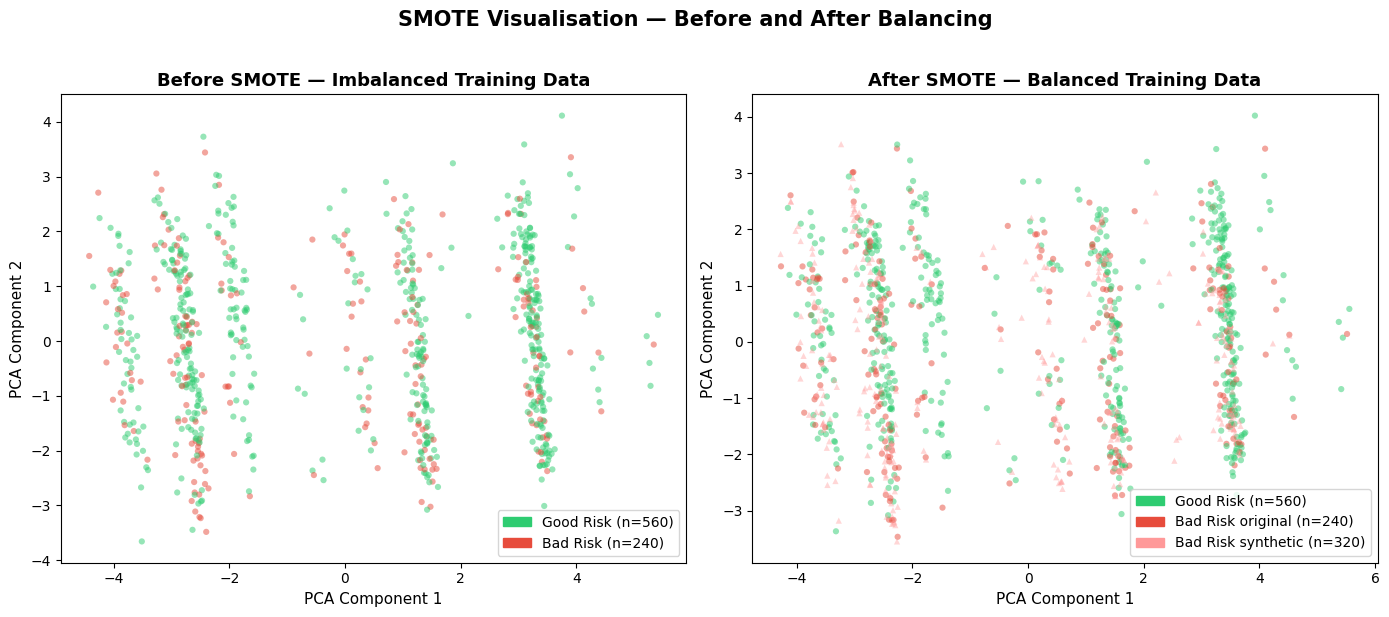

Chart saved successfully!


In [19]:
# ─── Visualise SMOTE effect ────────────────────────────────────────────────────
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ─── Reduce to 2D using PCA ───────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)

# Before SMOTE
X_train_pca = pca.fit_transform(X_train)

# After SMOTE
X_smote_pca = pca.fit_transform(X_train_smote)

# ─── Left chart: Before SMOTE ─────────────────────────────────────────────────
colors_before = ['#2ecc71' if c == 0 else '#e74c3c' for c in y_train]
axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                c=colors_before, alpha=0.5, s=20, edgecolors='none')
axes[0].set_title('Before SMOTE — Imbalanced Training Data',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('PCA Component 1', fontsize=11)
axes[0].set_ylabel('PCA Component 2', fontsize=11)
good_patch = mpatches.Patch(color='#2ecc71', label=f'Good Risk (n=560)')
bad_patch = mpatches.Patch(color='#e74c3c', label=f'Bad Risk (n=240)')
axes[0].legend(handles=[good_patch, bad_patch], fontsize=10)

# ─── Right chart: After SMOTE ─────────────────────────────────────────────────
# Separate original vs synthetic samples
original_mask = list(range(len(y_train)))
colors_after = ['#2ecc71' if c == 0 else '#e74c3c' 
                for c in y_train_smote[:len(y_train)]]
synthetic_colors = ['#ff9999' 
                    for _ in y_train_smote[len(y_train):]]

# Plot original samples
axes[1].scatter(X_smote_pca[:len(y_train), 0],
                X_smote_pca[:len(y_train), 1],
                c=colors_after, alpha=0.5, s=20, edgecolors='none')

# Plot synthetic samples in lighter red
axes[1].scatter(X_smote_pca[len(y_train):, 0],
                X_smote_pca[len(y_train):, 1],
                c='#ff9999', alpha=0.4, s=20, 
                edgecolors='none', marker='^')

axes[1].set_title('After SMOTE — Balanced Training Data',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('PCA Component 1', fontsize=11)
axes[1].set_ylabel('PCA Component 2', fontsize=11)

good_patch2 = mpatches.Patch(color='#2ecc71', label='Good Risk (n=560)')
bad_patch2 = mpatches.Patch(color='#e74c3c', label='Bad Risk original (n=240)')
syn_patch = mpatches.Patch(color='#ff9999', label='Bad Risk synthetic (n=320)')
axes[1].legend(handles=[good_patch2, bad_patch2, syn_patch], fontsize=10)

plt.suptitle('SMOTE Visualisation — Before and After Balancing',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/09_smote_visualisation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully!")

## 6. Saving Processed Data

We save the final processed datasets — the SMOTE balanced training set 
and the untouched test set — as CSV files ready for model training in 
Phase 4. Saving these files means we never need to rerun the entire 
preprocessing pipeline before training — we simply load the ready files 
directly into our model training notebook.

In [20]:
# ─── Save processed datasets ───────────────────────────────────────────────────
import os

# Convert to dataframes for saving
X_train_final = pd.DataFrame(X_train_smote, columns=X_train.columns)
y_train_final = pd.Series(y_train_smote, name='Category')
X_test_final = pd.DataFrame(X_test, columns=X_test.columns)
y_test_final = pd.Series(y_test, name='Category')

# Save all four files
X_train_final.to_csv('../data/processed/X_train.csv', index=False)
y_train_final.to_csv('../data/processed/y_train.csv', index=False)
X_test_final.to_csv('../data/processed/X_test.csv', index=False)
y_test_final.to_csv('../data/processed/y_test.csv', index=False)

print("All processed files saved successfully!")
print(f"\nFiles saved to data/processed/:")
print(f"  X_train.csv — {X_train_final.shape} — SMOTE balanced training features")
print(f"  y_train.csv — {y_train_final.shape} — SMOTE balanced training target")
print(f"  X_test.csv  — {X_test_final.shape} — Original test features")
print(f"  y_test.csv  — {y_test_final.shape} — Original test target")
print(f"\nPhase 3 — Feature Engineering — COMPLETE!")

All processed files saved successfully!

Files saved to data/processed/:
  X_train.csv — (1120, 20) — SMOTE balanced training features
  y_train.csv — (1120,) — SMOTE balanced training target
  X_test.csv  — (200, 20) — Original test features
  y_test.csv  — (200,) — Original test target

Phase 3 — Feature Engineering — COMPLETE!


## Data Governance Note

X_train.csv and y_train.csv contain SMOTE balanced training data 
generated before the data leakage issue was identified in Phase 4.

These files are preserved for audit trail purposes only.
They are NOT used in any downstream phase of this pipeline.
All subsequent phases use X_train_orig.csv and y_train_orig.csv
with SMOTE applied correctly inside Pipeline folds.